In [1]:
# import classy and other modules
from classy import Class
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
# to start the demo in clean conditions, erase any previous folder 'loop_matrices' and create a clean one
from shutil import rmtree
rmtree('loop_matrices/')
from os import mkdir
mkdir('loop_matrices/')  

In [3]:
# create an instance of class, "model", and set cosmological parameters 
model=Class()
model.set({
    'omega_b':'0.022445',
    'omega_cdm':'0.1200',
    'h':'0.6736',
    'n_s':'0.9649',
    'A_s':'2.100549e-09'
})

True

In [4]:
# set parameters specific to OneLoop module
# we require a full calculation of spectrum in redhsift space,
# including the initial calculation of the loop kernels, which is slow 
model.set({
    ######################################################################################
    # general settings: compute power spectrum with OneLoop module including RSD
    'output':'mPk',
    'non_linear':'oneloopPT',
    'has_rsd':'yes',
    #######################################################################################
    # parameters related to loop kernel calculation:
    'eft_compute_loop_matrices':'yes', # full calculation of the loop kernels (bottleneck)
    # after the first run the loop kernels can be written in files for future runs
    'eft_write_loop_matrices':'yes',
    'eft_loop_matrix_dir':'loop_matrices/',
    ########################################################################################
    # parameters related to logairthmic Fourier Transform logFT representation and transofrmation
    'eft_direct_integration':'no',     # switches on the logFT approach
    'eft_fourier_mode':1,              # either Fast Fourier Transform FFTlog (=0) or Spline Fourier Transform SFTlog (=1)
    'eft_num_positive_frequencies':96, #number of logFT coefficients (with SFTlog, 96 accurate enough; with FFTlog, 256 preferable)
    #########################################################################################
    # parameter related to redshift
    # will following settings, loops computed at z=0, then P(k,z) can be rescaled up to z=2 using D(z) and f(z)
    'eft_use_eds_scaling':'yes',
    'z_max_pk':2.
    # There exists other settings were loops are explicitely computed at various redshift
    ##########################################################################################
})

True

In [5]:
# run CLASS with a timer. If this is the first run, loop kernels are not cached, and the code is slow (3-4 seconds?)
start = time.time()
model.compute()
end = time.time()
print("Running CLASS including full loop kernel calculation (bottleneck) took %3.2g seconds"%(end-start))

Running CLASS including full loop kernel calculation (bottleneck) took 3.3 seconds


In [6]:
# set up the power spectrum output format
z     = [0.5, 1.5]
mu    = [0, 0.5, 1]
k_min = 0.001
k_max = 0.25
knum  = 500

# transform these arrays into correct data type for the classy function to handle
nbin  = len(z)
nmu   = len(mu)
z     = np.array(z, 'float64')                                                              #[index_z]
mu    = np.tile(np.array(mu, dtype='float64'), (nbin, 1))                                   #[index_z, index_mu]
k     = np.tile(np.logspace(np.log10(k_min), np.log10(k_max), num=knum), (nbin, nmu, 1))    #[index_z, index_mu, index_k]

In [7]:
# set up nuisance parameters (biases and counter terms)
b1, b2, bG2, btd   = 1., -0.7, -0.2 , 0.2
c00, c10, c22, c32 = -10., 20., 20., 20.
biases = np.tile(np.array([b1, b2, bG2, btd], dtype='float64'), (nbin, 1))                  #[index_z, index_bias]
counters = np.tile(np.array([c00, c10, 0., c22, 0., c32, 0.], dtype='float64'), (nbin,1))   #[index_z, index_counter]
# note: since the stochastic term contribution is a trivial analytic function,
# there is no need to include it in CLASS, it can be added later by the user

# compute the oneloop power spectrum wedges for biased tracers inr redshift space
pkmu_type = 'Pdd_hh_rsd'
start = time.time()
P1 = model.eft_pkmu_rsd_grid(
    mu,
    k,
    z,
    biases,
    counters,
    pkmu_type
)
end = time.time()
print("Without re-runing CLASS, extracting P_oneloop took %3.2g seconds"%(end-start))

Without re-runing CLASS, extracting P_oneloop took 0.002 seconds


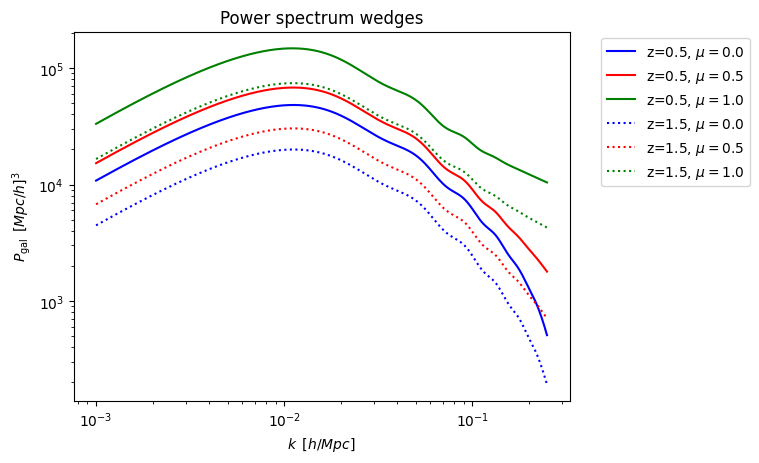

In [8]:
# plot the oneloop power spectrum wedges for biased tracers in redshift space
plt.subplot(111)
plt.loglog()
plt.gca().set_prop_cycle(None)
ls = ['-',':']
col = ['b','r','g']
for z_ind in range(len(z)):
    for mu_ind in range(nmu):
        plt.plot(k[z_ind][mu_ind], P1[z_ind][mu_ind], label="z=%s, $\mu=%s$" % (z[z_ind],mu[z_ind][mu_ind]),linestyle=ls[z_ind],color=col[mu_ind])
plt.xlabel("$k \,\,\, [h/Mpc]$")
plt.ylabel(r"$P_{\rm gal} \,\,\, [Mpc/h]^3$")
plt.title("Power spectrum wedges")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

In [9]:
# set up different nuisance parameters (in this exemple we just change c00), no need to rerun CLASS
b1, b2, bG2, btd   = 1., -0.7, -0.2 , 0.2
c00, c10, c22, c32 = -0., 20., 20., 20.
biases = np.tile(np.array([b1, b2, bG2, btd], dtype='float64'), (nbin, 1))                  #[index_z, index_bias]
counters = np.tile(np.array([c00, c10, 0., c22, 0., c32, 0.], dtype='float64'), (nbin,1))   #[index_z, index_counter]

# compute the oneloop power spectrum wedges for biased travecers inr redshift space
pkmu_type = 'Pdd_hh_rsd'
start = time.time()
P2 = model.eft_pkmu_rsd_grid(
    mu,
    k,
    z,
    biases,
    counters,
    pkmu_type
)
end = time.time()
print("Without re-runing CLASS, extracting another P_oneloop took %3.2g seconds"%(end-start))
print("This shows that nuisance parameters would play the role of fast parameters in an MCMC")

Without re-runing CLASS, extracting another P_oneloop took 0.002 seconds
This shows that nuisance parameters would play the role of fast parameters in an MCMC


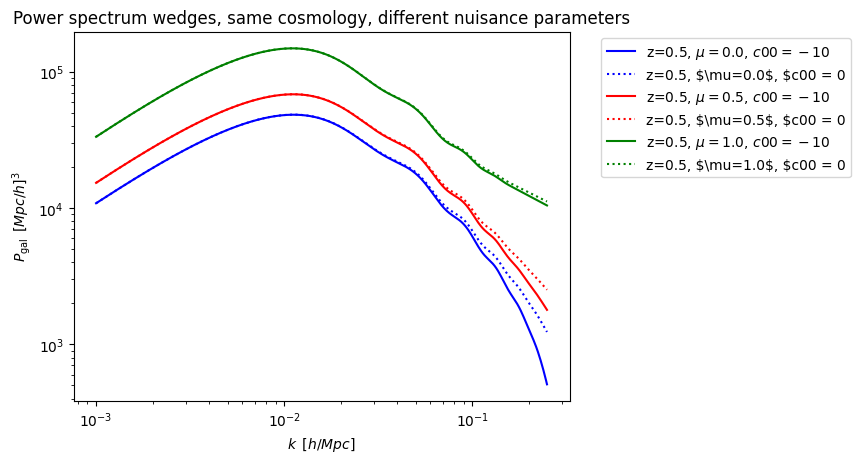

In [10]:
# plot the oneloop power spectrum wedges for biased tracers in redshift space
plt.loglog()
z_ind=0
for mu_ind in range(nmu):
    plt.plot(k[z_ind][mu_ind], P1[z_ind][mu_ind], label="z=%s, $\mu=%s$, $c00 = -10$" % (z[z_ind],mu[z_ind][mu_ind]),linestyle=ls[0],color=col[mu_ind])
    plt.plot(k[z_ind][mu_ind], P2[z_ind][mu_ind], label="z=%s, $\mu=%s$, $c00 = 0" % (z[z_ind],mu[z_ind][mu_ind]),linestyle=ls[1],color=col[mu_ind])
plt.xlabel("$k \,\,\, [h/Mpc]$")
plt.ylabel(r"$P_{\rm gal} \,\,\, [Mpc/h]^3$")
plt.title("Power spectrum wedges, same cosmology, different nuisance parameters")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

In [11]:
# new set of cosmological parameters
model.set({
    'omega_b':'0.023',
    'omega_cdm':'0.1200',
    'h':'0.68',
    'n_s':'0.997',
    'A_s':'2.1e-09'
})

# either force a new calculation of loop kernels, or re-used the cached one 
# (loop kernels are cosmology-independent, up to the choice of an optimal logFT bias,
#  and thus, up to possible ringing effects at extreme k values)
model.set({
'eft_compute_loop_matrices':'no',
})

True

In [12]:
# run CLASS with a timer. If this is the second run, loop kernels are read and code is fast (10^-4 seconds?)
start = time.time()
model.compute()
end = time.time()
print("Running CLASS without the full loop kernel calculation took %3.2g seconds (total for all modules + OneLoop)"%(end-start))
print("This would be the time taken by CLASS when changing slow parameters in an MCMC")

Running CLASS without the full loop kernel calculation took 0.22 seconds
This would be the time taken by CLASS when changing slow parameters in an MCMC


In [14]:
# use the same set of nuisance parameters as in first example
b1, b2, bG2, btd   = 1., -0.7, -0.2 , 0.2
c00, c10, c22, c32 = -10., 20., 20., 20.
biases = np.tile(np.array([b1, b2, bG2, btd], dtype='float64'), (nbin, 1))                  #[index_z, index_bias]
counters = np.tile(np.array([c00, c10, 0., c22, 0., c32, 0.], dtype='float64'), (nbin,1))   #[index_z, index_counter]

# compute the oneloop power spectrum wedges for biased tracers in redshift space
pkmu_type = 'Pdd_hh_rsd'
start = time.time()
P3 = model.eft_pkmu_rsd_grid(
    mu,
    k,
    z,
    biases,
    counters,
    pkmu_type
)
end = time.time()
print("Extracting P_oneloop took %3.2g seconds"%(end-start))

Extracting P_oneloop took 0.0023 seconds


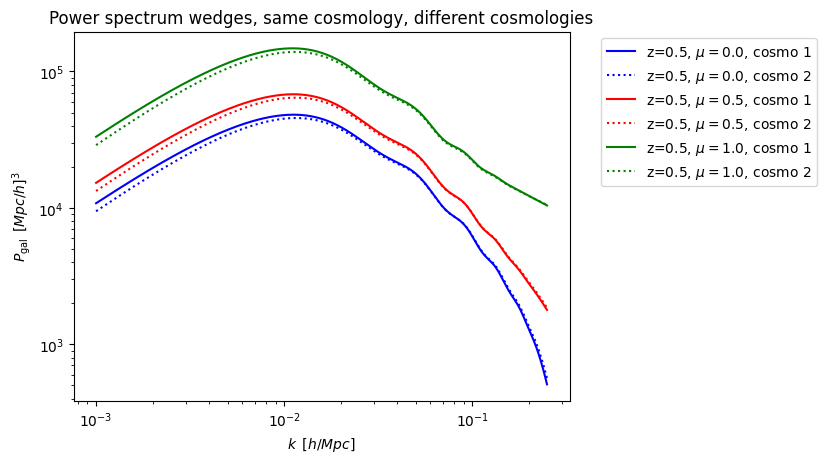

In [15]:
# plot the oneloop power spectrum wedges for biased travecers inr redshift space
plt.subplot(111)
plt.loglog()
z_ind = 0
for mu_ind in range(nmu):
    plt.plot(k[z_ind][mu_ind], P1[z_ind][mu_ind], label="z=%s, $\mu=%s$, cosmo 1" % (z[z_ind],mu[z_ind][mu_ind]),linestyle=ls[0],color=col[mu_ind])
    plt.plot(k[z_ind][mu_ind], P3[z_ind][mu_ind], label="z=%s, $\mu=%s$, cosmo 2" % (z[z_ind],mu[z_ind][mu_ind]),linestyle=ls[1],color=col[mu_ind])
plt.xlabel("$k \,\,\, [h/Mpc]$")
plt.ylabel(r"$P_{\rm gal} \,\,\, [Mpc/h]^3$")
plt.title("Power spectrum wedges, same cosmology, different cosmologies")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')